In [1]:
import scanpy as sc
import pandas as pd
import numpy as np

In [2]:
import os
import anndata as ad

In [3]:
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42

In [4]:
import seaborn as sns

In [5]:
from tripso.Evaluate.downstream import calculate_gene_significance, plot_top_genes


# Cosine similarity - JAKSTAT

In [6]:
def load_adata(run, output_name = 'global'):
    holder = []
    base_path = 'tripso_reproducibility/04.5_HSC_post_qc'
    

    for t in ['train', 'val', 'test']:
        target_path = 'jakstat_genes'
        dataset1 = 'JAK-STAT_cd34_hsc'
        filename = f'gene_to_JAK-STAT_cosine_similarity_{t}_set.h5ad'
        
        holder.append(
            sc.read_h5ad(os.path.join(base_path, f'{run}_by_study/output_{output_name}', target_path, dataset1, filename))
        )
        
    adata = ad.concat(holder)    
    
    return adata


In [7]:
run1 = load_adata('run_1')
run2 = load_adata('run_2')
run3 = load_adata('run_3')

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [8]:
adata = sc.AnnData(
    X = (run1.X + run2.X + run3.X)/3,
    obs = run1.obs,
    var = run1.var
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1754: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.


In [9]:
adata.var.head()

""
ENSG00000002549
ENSG00000003400
ENSG00000006210
ENSG00000010030
ENSG00000013374


In [10]:
# map ensembl to gene name 
from geneformer import ENSEMBL_DICTIONARY_FILE
name_to_ens = pd.read_pickle(ENSEMBL_DICTIONARY_FILE)
name_df = pd.DataFrame(
            list(name_to_ens.items()), columns=['gene', 'ensembl_id']
        )

convert_df = name_df[name_df['ensembl_id'].isin(adata.var_names)]

# gpdb_symbol = pd.read_csv('tripso_reproducibility/04.5_HSC_post_qc/gp_nw_all.csv')
gpdb_symbol = pd.read_csv('tripso_reproducibility/02.1_benchmarking_repeat/gpdb_progeny_200.csv')

convert_df = convert_df[convert_df['gene'].isin(gpdb_symbol['JAK-STAT'].values)]

In [11]:
adata.var = adata.var.join(convert_df.set_index('ensembl_id'))

In [12]:
adata.var = adata.var.set_index('gene')

In [19]:
adata.obs['tissue_binary'] = np.where(
    adata.obs['tissue'] == 'PBM', 
    'PBM', 
    'other',
)


In [20]:
res0 = calculate_gene_significance(
    adata[
        adata.obs['cell_type'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    obs_col="tissue_binary",
    obs_value_ref="other",
    obs_value_query="PBM",
    adata_gene_threshold=0.9, 
)

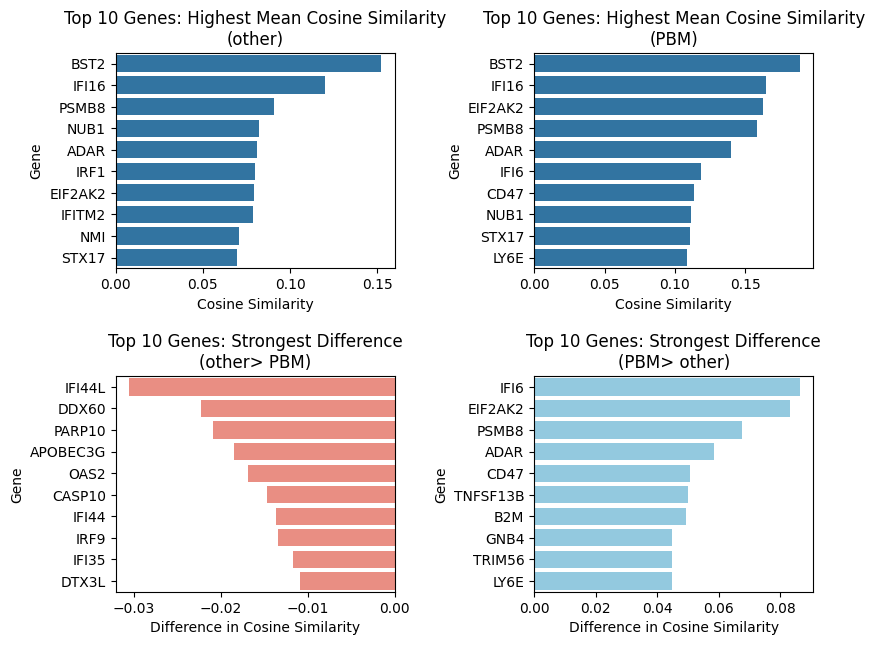

In [26]:
plot_top_genes(
    res0,
    obs_value_ref="other",
    obs_value_query="PBM",
    show_significance=False,
    color_scheme='default',
    significance_palette = ['#008B8B'],
    palette_as_gradient=False,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    save_to = 'jakstat_pbm_genes.pdf'
)



In [24]:
res0.sort_values(by = 'effect_size', ascending = False).head()

,gene,p_value,mean_ref,mean_query,effect_size,p_adjusted,significance
38,IFI6,0.0,0.032303,0.118708,0.086406,0.0,***
4,EIF2AK2,0.0,0.079567,0.162807,0.083241,0.0,***
109,PSMB8,0.0,0.090525,0.158190,0.067666,0.0,***
74,ADAR,0.0,0.080920,0.139457,0.058537,0.0,***
107,CD47,0.0,0.062835,0.113376,0.050542,0.0,***


In [23]:
res0.sort_values(by = 'effect_size', ascending = False)['gene'][:10].tolist()

['IFI6',
 'EIF2AK2',
 'PSMB8',
 'ADAR',
 'CD47',
 'TNFSF13B',
 'B2M',
 'GNB4',
 'TRIM56',
 'LY6E']

In [17]:
res0.sort_values(by = 'effect_size')['gene'][:10].tolist()

['IFI44L',
 'DDX60',
 'PARP10',
 'APOBEC3G',
 'OAS2',
 'CASP10',
 'IFI44',
 'IRF9',
 'IFI35',
 'DTX3L']

In [18]:
pd.crosstab(
    adata.obs['cell_type'],
    adata.obs['tissue_binary']
)
    

tissue_binary,PBM,other
cell_type,,
1_LT-HSC,1013,5462
2_ST-HSC,247,8620
3_MPP,2424,19516
4_MEMP,411,4675
5_MK,123,1546
6_Early_Ery,725,9935
7_Late_Ery,73,2530
8_BaEoMa,133,1476
9_LMPP,582,2857


# vs prenatal

In [19]:
res1 = calculate_gene_significance(
    adata[
        adata.obs['cell_type'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP']) &
        adata.obs['tissue'].isin(['PBM', 'FL', 'FBM', 'YS', 'CB'])
    ],
    obs_col="tissue_binary",
    obs_value_ref="other",
    obs_value_query="PBM",
    adata_gene_threshold=0.9, 
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


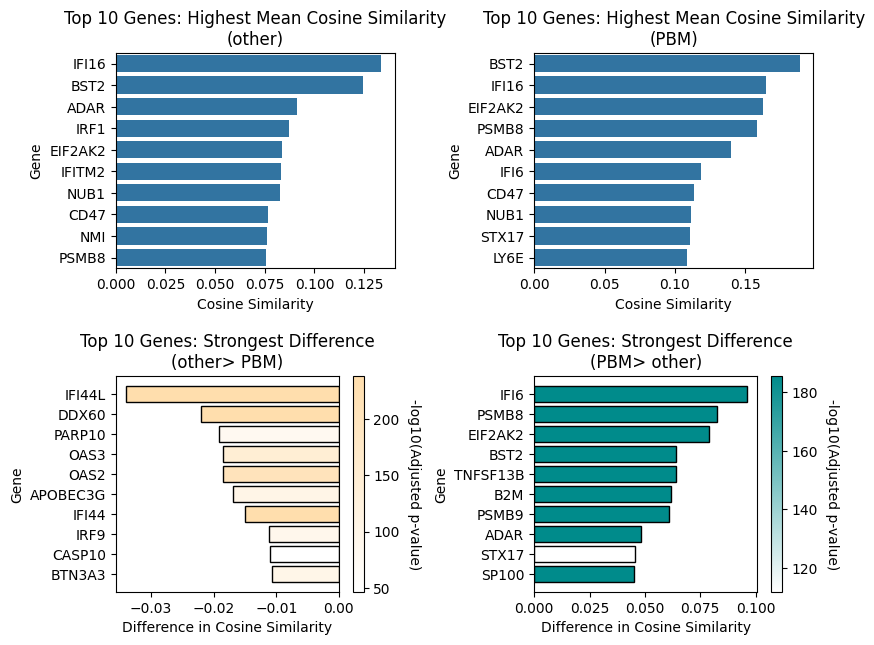

In [20]:
plot_top_genes(
    res1,
    obs_value_ref="other",
    obs_value_query="PBM",
    show_significance=False,
    color_scheme='significance',
    significance_palette = ['#FFDEAD', '#008B8B'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    # save_to = 'large_pre_B.pdf'
)



# vs adult

In [21]:
res2 = calculate_gene_significance(
    adata[
        adata.obs['cell_type'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP']) &
        (adata.obs['tissue'].str.contains('PBM')  | adata.obs['tissue'].str.contains('ABM'))
    ],
    obs_col="tissue_binary",
    obs_value_ref="other",
    obs_value_query="PBM",
    adata_gene_threshold=0.9, 
)

/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2196: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 0].set_yticklabels(yticklabels)
/nfs/team361/mm58/tripso/tripso/Evaluate/downstream.py:2281: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1, 1].set_yticklabels(yticklabels)


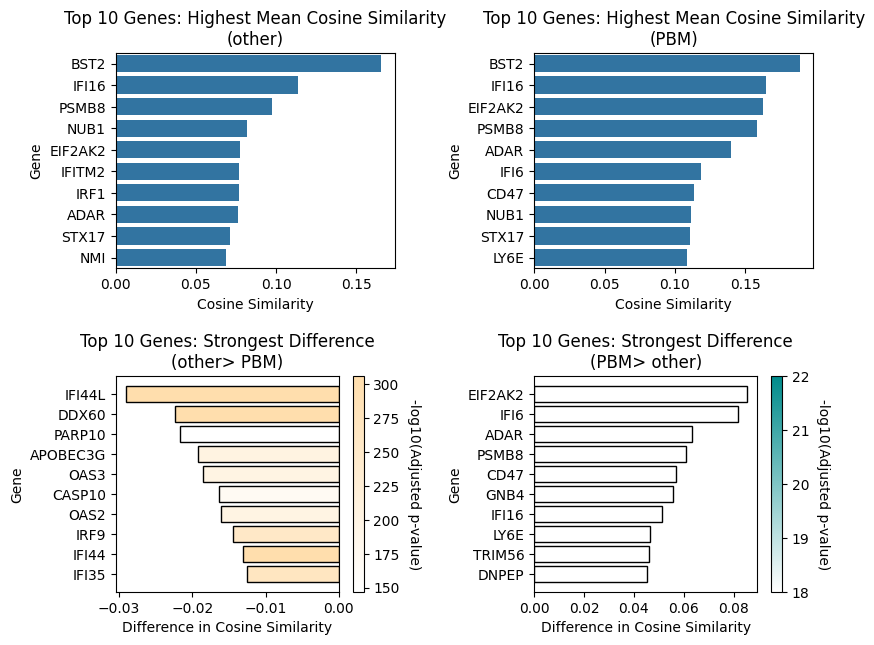

In [22]:
plot_top_genes(
    res2,
    obs_value_ref="other",
    obs_value_query="PBM",
    show_significance=False,
    color_scheme='significance',
    significance_palette = ['#FFDEAD', '#008B8B'],
    palette_as_gradient=True,   # uses the two colors to build gradients
    topn=10,
    figsize = (9,7),
    # save_to = 'large_pre_B.pdf'
)



# Check in original gene expression

In [23]:
cd34 = sc.read_h5ad(
    'tripso_reproducibility/04.5_HSC_post_qc/data/raw/CD34_RNA_98266cells_to_share.h5ad'
)


In [24]:
cd34.X = cd34.layers['log_counts']

In [25]:

cd34.obs['donor'] = cd34.obs['donor_tissue'].str.extract(r'^([^_]+)_')


# update obs to match Tomo
cd34.obs['tissue'] = np.where(
    cd34.obs['tissue'] == 'EL',
    'FL', 
    cd34.obs['tissue']
)

# separate young and aged in adult BM
# categorise age groups { end with PCW : 'Fetal, 0-15: Pediatric, 16-30 : Young Adult, 31-50:  Middle Age, 50+: Aged}
cd34.obs['age_group'] = None
cd34.obs.loc[(cd34.obs['age'].str.contains('PCW')) , 'age_group'] = 'Fetal'
cd34.obs.loc[(cd34.obs['age']=='0') , 'age_group'] = 'Cord Blood'
# replace all PCW rows with empty string, e.g. 14PCW -> ''
cd34.obs['age'] = cd34.obs['age'].str.replace(r'\d+PCW', '', regex=True)
cd34.obs['age'] = cd34.obs['age'].replace('', np.nan)
cd34.obs['age'] = cd34.obs['age'].astype(float)

# distinguish between aged bone marrow Aged (60+) and young (<60)
cd34.obs['tissue'] = pd.Categorical(cd34.obs['tissue'])
cd34.obs['tissue'] = cd34.obs['tissue'].cat.add_categories(['ABM_+60y', 'ABM_29-50y']) # 'PBM'
cd34.obs.loc[cd34.obs['age'] >= 60, 'tissue'] = 'ABM_+60y'
cd34.obs.loc[(cd34.obs['age'] < 60) & (cd34.obs['age'] >= 17), 'tissue'] = 'ABM_29-50y'
cd34.obs.loc[(cd34.obs['age'] < 17) & (cd34.obs['age'] >= 1), 'tissue'] = 'PBM'

cd34.obs['tissue'] = cd34.obs['tissue'].cat.remove_unused_categories()


cd34.obs['tissue'] = cd34.obs['tissue'].cat.reorder_categories(
    ['YS', 'FL', 'FBM', 'CB', 'PBM', 'ABM_29-50y', 'ABM_+60y']
    )


/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


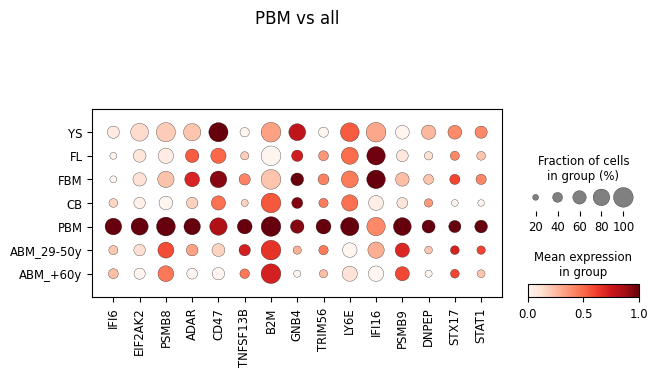

In [29]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    res0.sort_values(by = 'effect_size', ascending = False)['gene'][:15].tolist(),
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'PBM vs all', 
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


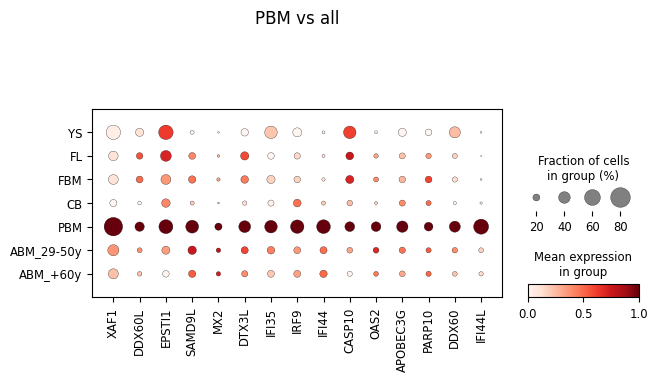

In [32]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    res0.sort_values(by = 'effect_size', ascending = False)['gene'][-15:].tolist(),
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'PBM vs all', 
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


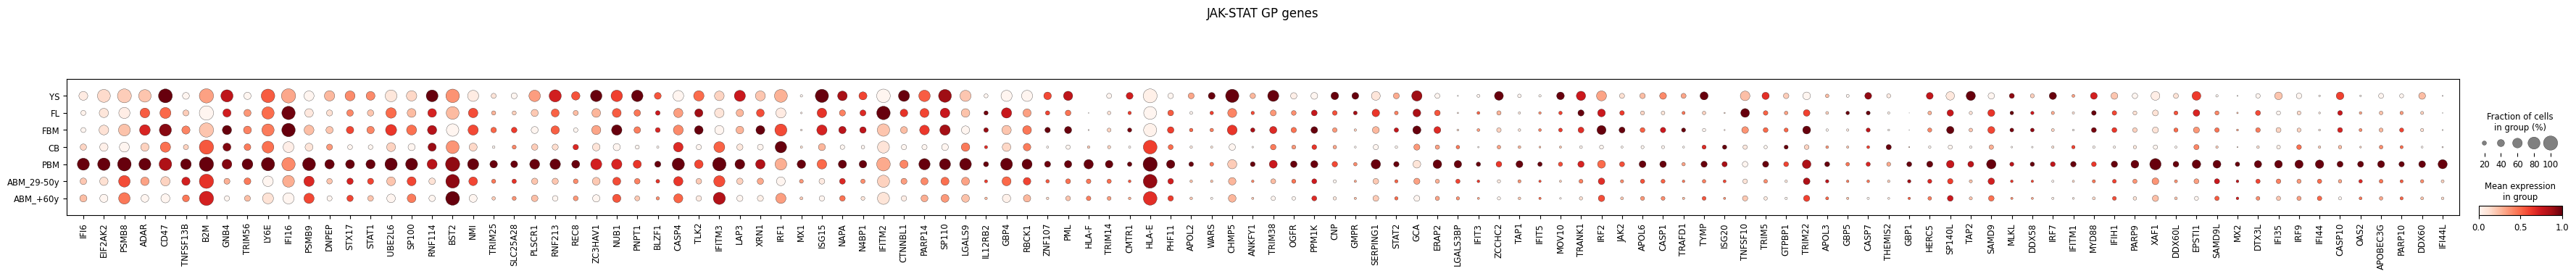

In [35]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    [g for g in res0.sort_values(by = 'effect_size', ascending = False)['gene'].tolist() if g in cd34.var_names],
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'JAK-STAT GP genes', 
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


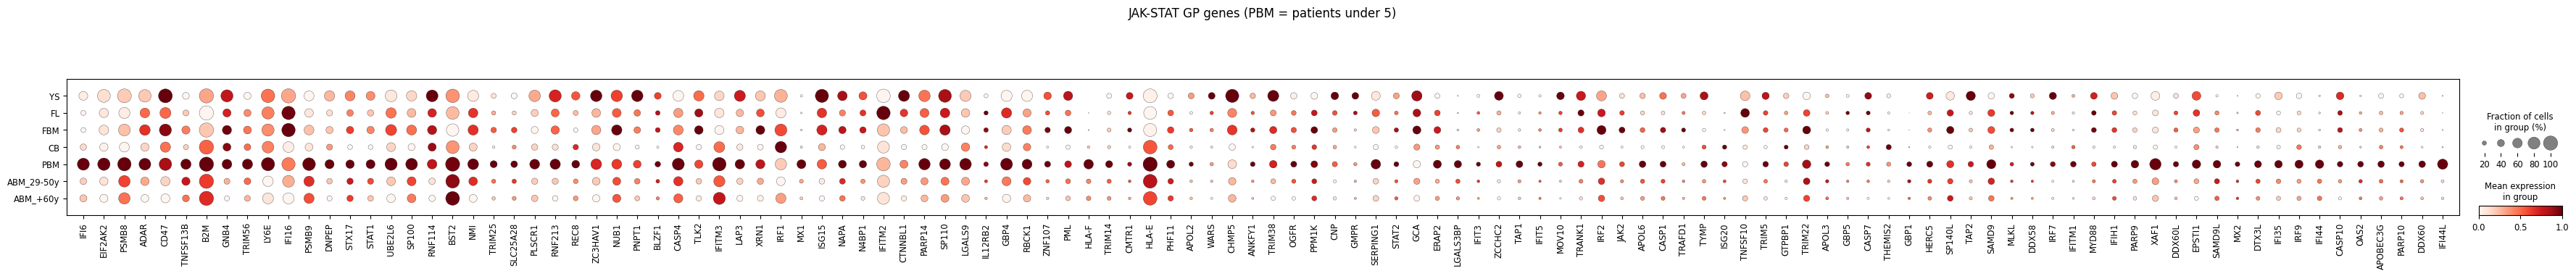

In [41]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP']) &
        (cd34.obs['age'].isin([1.4, 4.5]) | (cd34.obs['tissue'] != 'PBM'))
    ],
    [g for g in res0.sort_values(by = 'effect_size', ascending = False)['gene'].tolist() if g in cd34.var_names],
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'JAK-STAT GP genes (PBM = patients under 5)', 
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


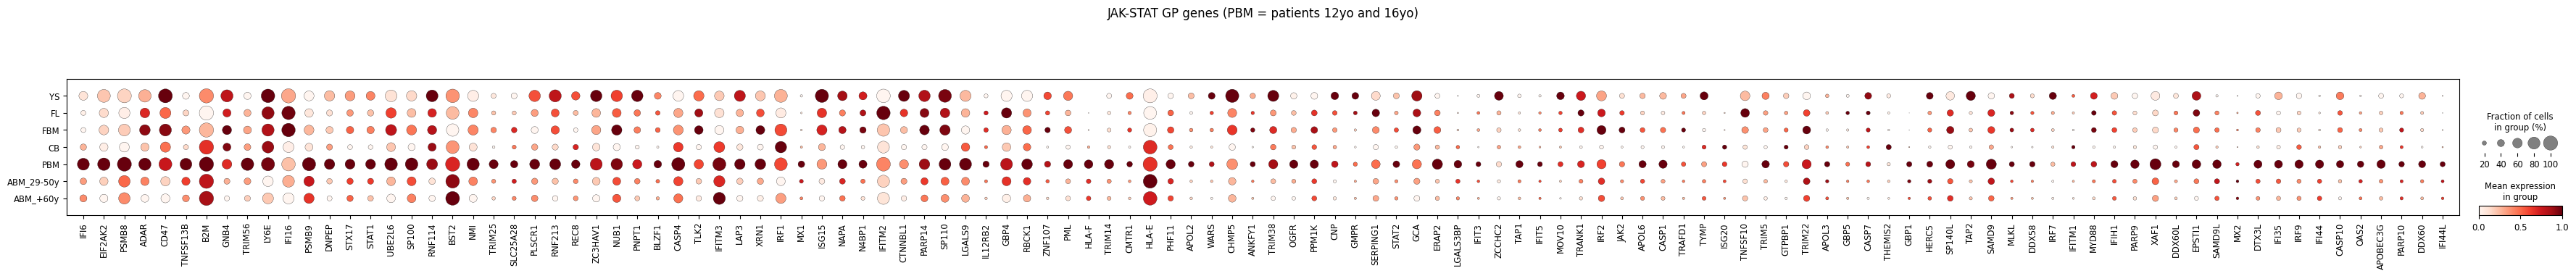

In [42]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP']) &
        (cd34.obs['age'].isin([12.0, 16.5]) | (cd34.obs['tissue'] != 'PBM'))
    ],
    [g for g in res0.sort_values(by = 'effect_size', ascending = False)['gene'].tolist() if g in cd34.var_names],
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'JAK-STAT GP genes (PBM = patients 12yo and 16yo)', 
)

In [36]:
cd34[cd34.obs['tissue'] == 'PBM'].obs['age'].value_counts()

age
1.4     8188
4.5     3484
12.0    2811
16.5     887
Name: count, dtype: int64

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


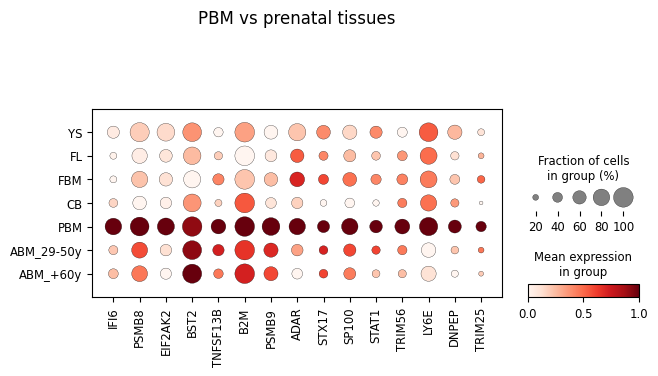

In [30]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    res1.sort_values(by = 'effect_size', ascending = False)['gene'][:15].tolist(),
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'PBM vs prenatal tissues', 
)

/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.
/software/cellgen/team292/mm58/venvs/lightning2/lib/python3.10/site-packages/anndata/_core/anndata.py:1145: Trying to modify attribute `.obs` of view, initializing view as actual.


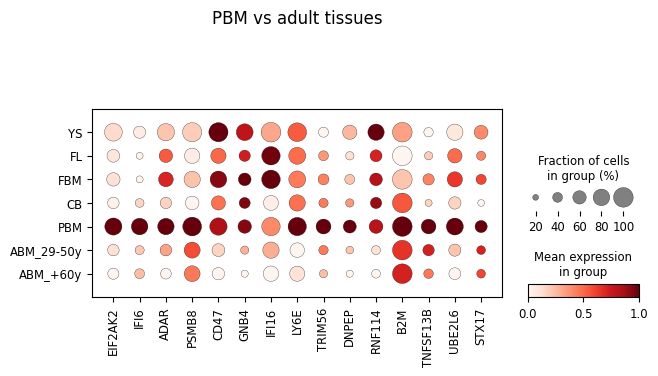

In [31]:
sc.pl.dotplot(
    cd34[
        cd34.obs['celltype_v2'].isin(['1_LT-HSC', '2_ST-HSC', '3_MPP'])
    ],
    res2.sort_values(by = 'effect_size', ascending = False)['gene'][:15].tolist(),
    groupby = 'tissue', 
    standard_scale = 'var',
    title = 'PBM vs adult tissues', 
)